:::{canonical-tutorial} tutorials/basics/integrating-data-using-ingest
:::

# Integrating data using ingest and BBKNN

**대칭적 데이터 통합 (예: BBKNN)**
* 정의: 모든 데이터셋을 동등하게 취급하여 하나의 공통된 통합된 공간을 학습하는 방식입니다. 모든 데이터셋이 이 통합 공간을 정의하는 데 기여하며, 결과적으로 각 데이터셋의 개별적인 특성보다는 공통된 생물학적 변이가 강조됩니다.
* ** 목표: 서로 다른 배치(batch)에서 유래한 데이터 간의 기술적 변이(배치 효과)를 제거하고, 생물학적으로 유사한 세포들이 통합된 공간에서 서로 가깝게 위치하도록 만듭니다. 모든 데이터셋의 세포들이 잘 섞이는 것을 목표로 합니다. **
* 특징: 새로운 데이터를 추가할 때마다 전체 통합 과정을 다시 수행해야 할 수 있습니다. 여러 배치 간의 비교와 통합된 분석에 유리합니다.
* 튜토리얼 예시: BBKNN은 대표적인 대칭적 통합 도구입니다. 튜토리얼에서 Pancreas 데이터셋에 BBKNN을 적용했을 때, batch 간의 구분이 UMAP 플롯에서 많이 사라지고 celltype별로 세포들이 잘 섞인 것을 볼 수 있었습니다.

**비대칭적 데이터 통합 (예: scanpy.tl.ingest)**
* 정의: 하나의 데이터셋을 '참조(reference)'로 지정하고, 다른 데이터셋('쿼리(query)')을 이 참조 데이터셋의 구조에 맞춰 매핑하는 방식입니다. 참조 데이터셋이 주된 생물학적 변이를 정의하며, 쿼리 데이터는 이 참조의 모델을 따릅니다.
* ** 목표: 참조 데이터셋에 이미 존재하는 레이블(예: 세포 유형)이나 임베딩(예: UMAP 좌표)을 새로운 쿼리 데이터에 '섭취(ingest)'하여 적용하는 것입니다. 참조 데이터의 안정적인 구조를 유지하면서 새로운 데이터를 그 안에 삽입하는 데 중점을 둡니다. **
* 특징: 참조 데이터의 구조가 유지되므로, 참조 데이터에 있는 특정 클러스터나 궤적이 새로운 데이터에서도 동일하게 나타나기를 원할 때 유용합니다. 새로운 쿼리 데이터가 들어와도 참조 데이터 모델만 있다면 빠르게 매핑할 수 있습니다.
* 튜토리얼 예시: scanpy.tl.ingest는 비대칭적 통합 도구입니다. 튜토리얼에서 PBMC 데이터셋과 Pancreas 데이터셋 모두에서 adata_ref를 사용하여 adata를 매핑했습니다. 이 방식은 BBKNN보다 클러스터 구조를 더 명확하게 유지하는 경향이 있다고 설명되었습니다.

In [ ]:
from __future__ import annotations

!pip install anndata
!pip install scanpy
import anndata
import pandas as pd
import scanpy as sc

In [ ]:
sc.settings.verbosity = 1  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_versions()
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(3, 3), facecolor="white")

/tmp/ipykernel_2294/174976041.py:2: FutureWarning: Use `print_header` instead
  sc.logging.print_versions()
/tmp/ipykernel_2294/174976041.py:3: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(3, 3), facecolor="white")


## PBMCs

adata_ref->adata (ingest) : adata_ref으로 adata annotation

In [ ]:
# this is an earlier version of the dataset from the pbmc3k tutorial
adata_ref = sc.datasets.pbmc3k_processed()
adata = sc.datasets.pbmc68k_reduced()

  0%|          | 0.00/23.5M [00:00<?, ?B/s]

To use `sc.tl.ingest`, the datasets need to be defined on the same variables.

In [ ]:
var_names = adata_ref.var_names.intersection(adata.var_names) #공통GENE찾기
adata_ref = adata_ref[:, var_names].copy()
adata = adata[:, var_names].copy()

The model and graph (here PCA, neighbors, UMAP) trained on the reference data will explain the biological variation observed within it.

In [ ]:
sc.pp.pca(adata_ref)
sc.pp.neighbors(adata_ref)
sc.tl.umap(adata_ref)

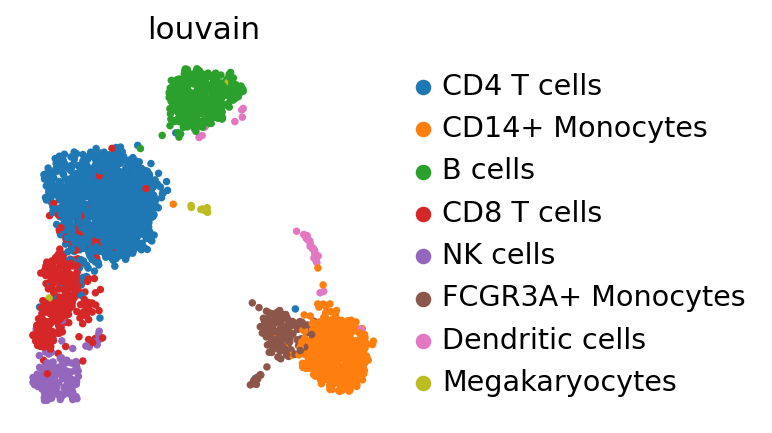

In [ ]:
sc.pl.umap(adata_ref, color="louvain")

### Mapping PBMCs using ingest

In [ ]:
sc.tl.ingest(adata, adata_ref, obs="louvain")

In [ ]:
adata.uns["louvain_colors"] = adata_ref.uns["louvain_colors"]  # fix colors

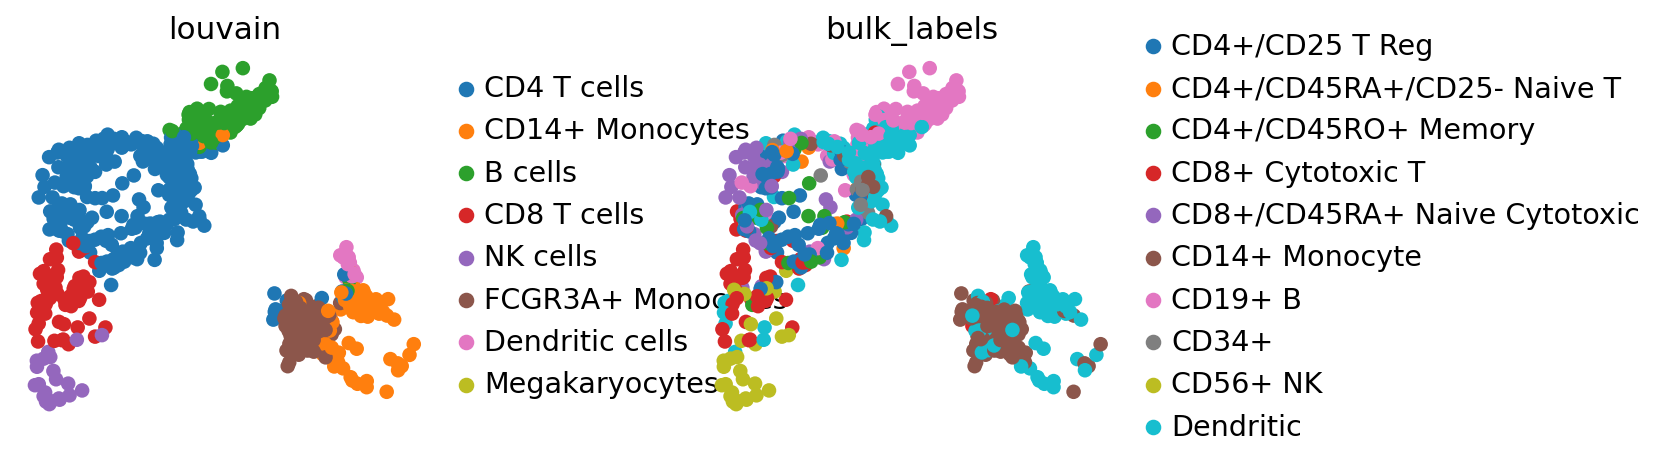

In [ ]:
sc.pl.umap(adata, color=["louvain", "bulk_labels"], wspace=0.5)

By comparing the 'bulk_labels' annotation with 'louvain', we see that the data has been reasonably mapped, only the annotation of dendritic cells seems ambiguous and might have been ambiiguous in `adata` already.

####ref와 query 겹쳐보기

In [ ]:
adata_concat = anndata.concat([adata_ref, adata], label="batch", keys=["ref", "new"])

In [ ]:
adata_concat.obs["louvain"] = (
    adata_concat.obs["louvain"].astype("category").cat.reorder_categories(adata_ref.obs["louvain"].cat.categories)
)
# fix category colors
adata_concat.uns["louvain_colors"] = adata_ref.uns["louvain_colors"]

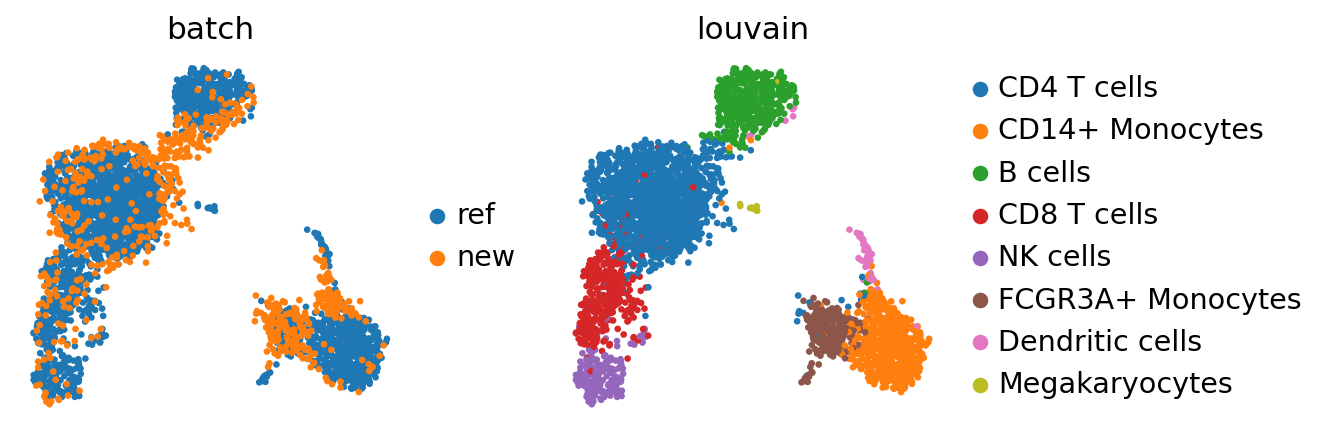

In [ ]:
sc.pl.umap(adata_concat, color=["batch", "louvain"])

While there seems to be some batch-effect in the monocytes and dendritic cell clusters, the new data is otherwise mapped relatively homogeneously.

The megakaryoctes are only present in `adata_ref` and no cells from `adata` map onto them. If interchanging reference data and query data, Megakaryocytes do not appear as a separate cluster anymore. This is an extreme case as the reference data is very small; but one should always question if the reference data contain enough biological variation to meaningfully accomodate query data.

-> reference data가 query data를 커버할 수 있어야(더 크고 다양해야)한다는 말

### Using BBKNN

In [ ]:
sc.tl.pca(adata_concat)

In [ ]:
%%time
!pip install bbknn
sc.external.pp.bbknn(adata_concat, batch_key="batch")  # running bbknn 1.3.6
#BBKNN 통합 알고리즘을 적용하여, 'batch' 컬럼에 기록된 batch 정보를 기반으로 batch 효과를 제거하고 세포들을 더 잘 섞이도록(통합되도록) 만드는 과정

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 7.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for annoy: filename=annoy-1.17.3-cp312-cp312-linux_x86_64.whl size=551806 sha256=77eca1c6d267781424a19d4c5c4f458293511f730728d93d4e5b3e517d179585
  Stored in directory: /root/.cache/pip/wheels/db/b9/53/a3b2d1fe1743abadddec6aa541294b24fdbc39d7800bc57311
Successfully built annoy
CPU times: user 3.84 s, sys: 231 ms, total: 4.08 s
Wall time: 31.3 s


In [ ]:
sc.tl.umap(adata_concat)

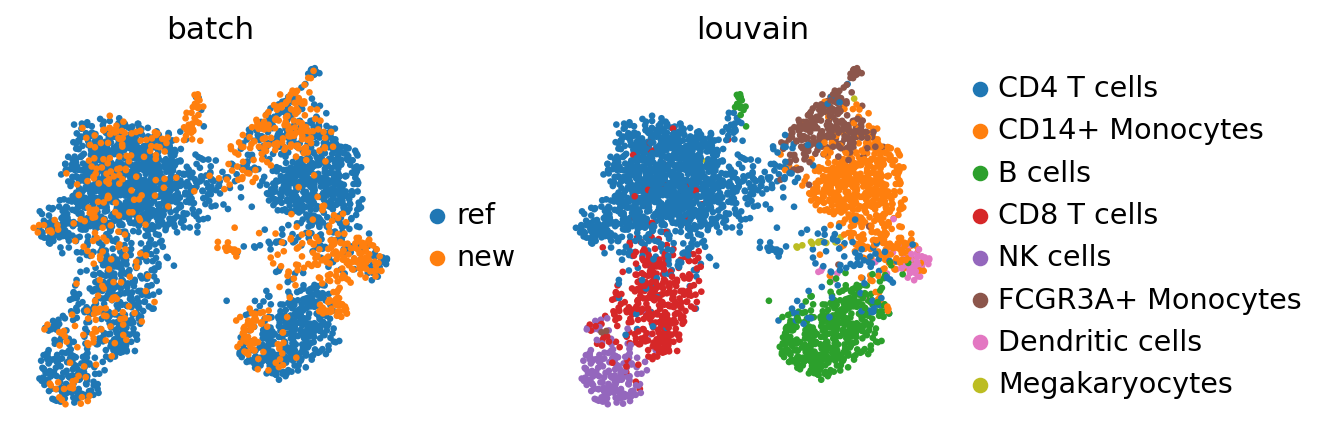

In [ ]:
sc.pl.umap(adata_concat, color=["batch", "louvain"])

megakaryocytes'라는 레이블은 여전히 존재하지만, 이 레이블을 가진 세포들이 UMAP 플롯 상에서 시각적으로 뚜렷한 클러스터로서의 형태를 유지하지 못한다.

-> ingest와의 차이점

## Pancreas

In [ ]:
# note that this collection of batches is already intersected on the genes
adata_all = sc.read(
    "data/pancreas.h5ad",
    backup_url="https://www.dropbox.com/s/qj1jlm9w10wmt0u/pancreas.h5ad?dl=1",
)

  0%|          | 0.00/176M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{
/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  return AnnData(**{


In [ ]:
adata_all.shape

(14693, 2448)

Inspect the cell types observed in these studies.

In [ ]:
counts = adata_all.obs["celltype"].value_counts()
counts.to_frame()

,count
celltype,
alpha,4214
beta,3354
ductal,1804
acinar,1368
not applicable,1154
delta,917
gamma,571
endothelial,289
activated_stellate,284


To simplify visualization, let's remove the 5 minority classes.

In [ ]:
minority_classes = counts.index[-5:].tolist()  # get the minority classes
# actually subset
adata_all = adata_all[~adata_all.obs["celltype"].isin(minority_classes)].copy()
# reorder according to abundance
adata_all.obs["celltype"] = adata_all.obs["celltype"].cat.reorder_categories(counts.index[:-5].tolist())

### Seeing the batch effect(통합되지 않은 cell) : 하나의 cell type이 여러 개의 cluster로 분리되어 있음

In [ ]:
sc.pp.pca(adata_all)
sc.pp.neighbors(adata_all)
sc.tl.umap(adata_all)

We observe a batch effect.

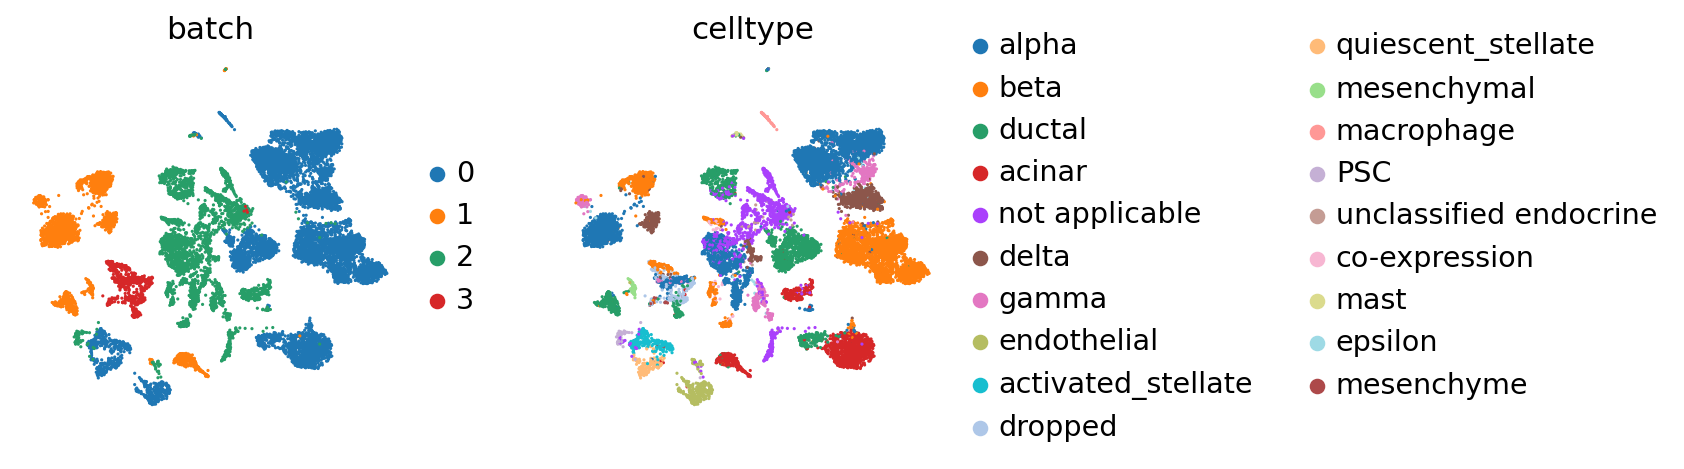

In [ ]:
sc.pl.umap(adata_all, color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy)

### BBKNN (batch effect 제거하고 통합된 cell) : cell 종류 별 단일 cluster

It can be well-resolved using [BBKNN](https://github.com/Teichlab/bbknn) {cite:p}`Polanski2019`.

In [ ]:
%%time
sc.external.pp.bbknn(adata_all, batch_key="batch")

CPU times: user 1.55 s, sys: 4.17 ms, total: 1.56 s
Wall time: 1.52 s


In [ ]:
sc.tl.umap(adata_all)

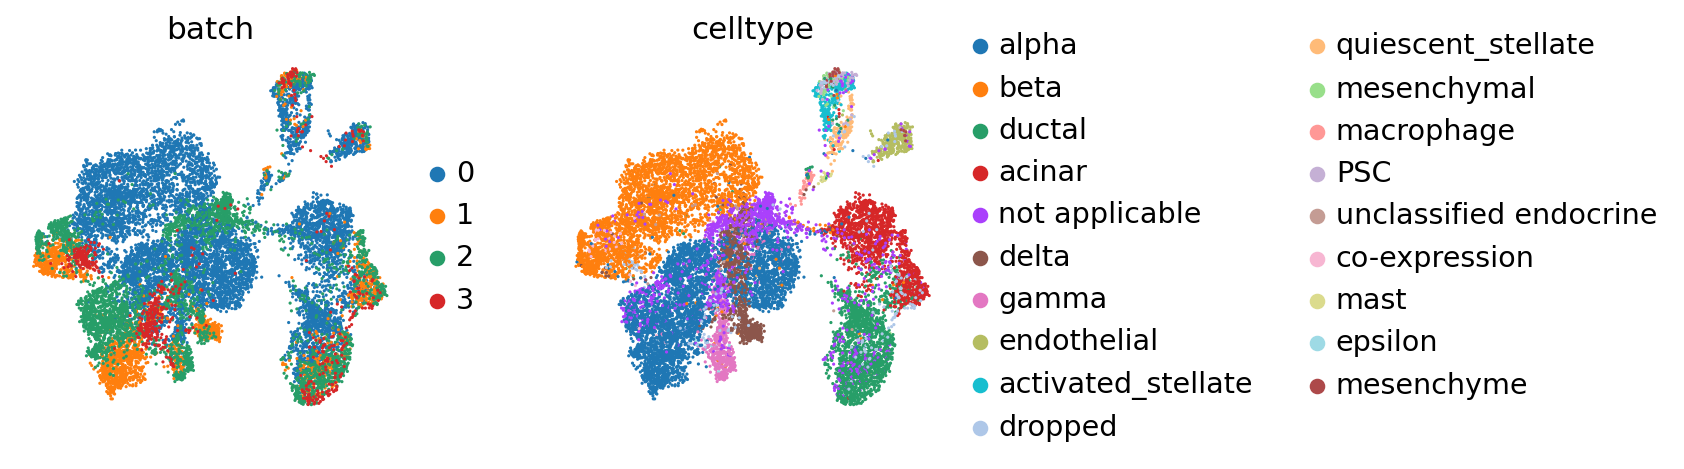

In [ ]:
sc.pl.umap(adata_all, color=["batch", "celltype"])

If one prefers to work more iteratively starting from one reference dataset, one can use ingest.

### Mapping onto a reference batch using ingest
: batch=0 으로 batch>0 재배치

**목표 : batch effect가 여전히 남아 있는 cell들 재배치해서 batch effect 없애기**

In [ ]:
#batch=0인 data만 뽑아서 ref만들기
adata_ref = adata_all[adata_all.obs["batch"] == "0"].copy()

Compute the PCA, neighbors and UMAP on the reference data.

In [ ]:
sc.pp.pca(adata_ref)
sc.pp.neighbors(adata_ref)
sc.tl.umap(adata_ref)

The reference batch contains 12 of the 19 cell types across all batches.

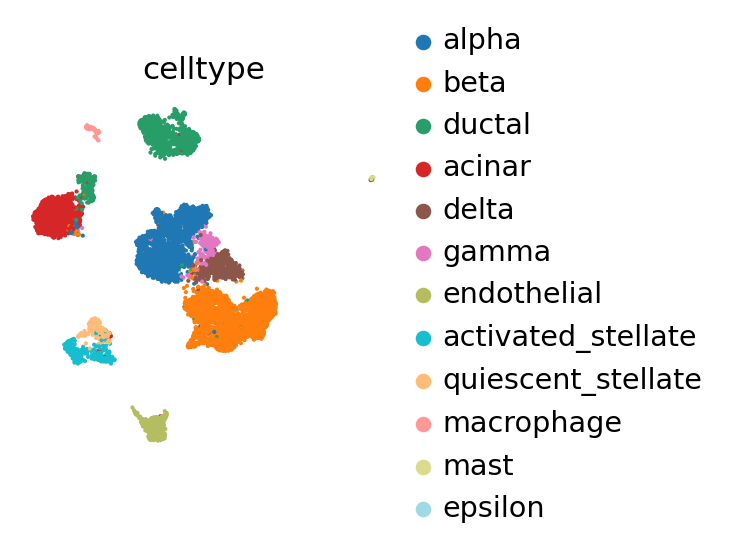

In [ ]:
sc.pl.umap(adata_ref, color="celltype")

In [ ]:
#batch>0인 cell들 query로 만들기
adatas = [adata_all[adata_all.obs["batch"] == i].copy() for i in ["1", "2", "3"]]

In [ ]:
sc.settings.verbosity = 2  # a bit more logging
for iadata, adata in enumerate(adatas, 1):
    print(f"... integrating batch {iadata}")
    adata.obs["celltype_orig"] = adata.obs["celltype"]  # save the original cell type (이후 비교 예정)
    sc.tl.ingest(adata, adata_ref, obs="celltype")

... integrating batch 1
running ingest
    finished (0:00:06)
... integrating batch 2
running ingest
    finished (0:00:07)
... integrating batch 3
running ingest
    finished (0:00:02)


In [ ]:
adata_concat = anndata.concat([adata_ref, *adatas], label="batch", join="outer")

In [ ]:
adata_concat.obs["celltype"] = (
    adata_concat.obs["celltype"].astype("category").cat.reorder_categories(adata_ref.obs["celltype"].cat.categories)
)
# fix category coloring
adata_concat.uns["celltype_colors"] = adata_ref.uns["celltype_colors"]

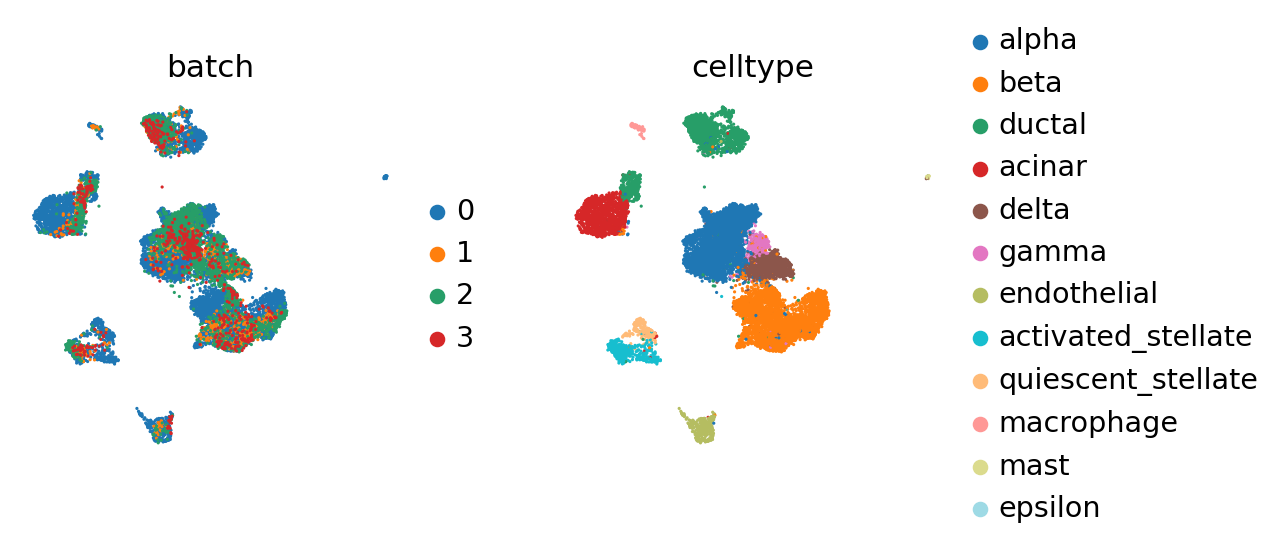

In [ ]:
sc.pl.umap(adata_concat, color=["batch", "celltype"])

Compared to the BBKNN result, this is maintained clusters in a much more pronounced fashion. If one already observed a desired continuous structure (as in the hematopoietic datasets, for instance), `ingest` allows to easily maintain this structure.

### Evaluating consistency

Let us subset the data to the query batches.

In [ ]:
adata_query = adata_concat[adata_concat.obs["batch"].isin(["1", "2", "3"])].copy()

The following plot is a bit hard to read, hence, move on to confusion matrices below.

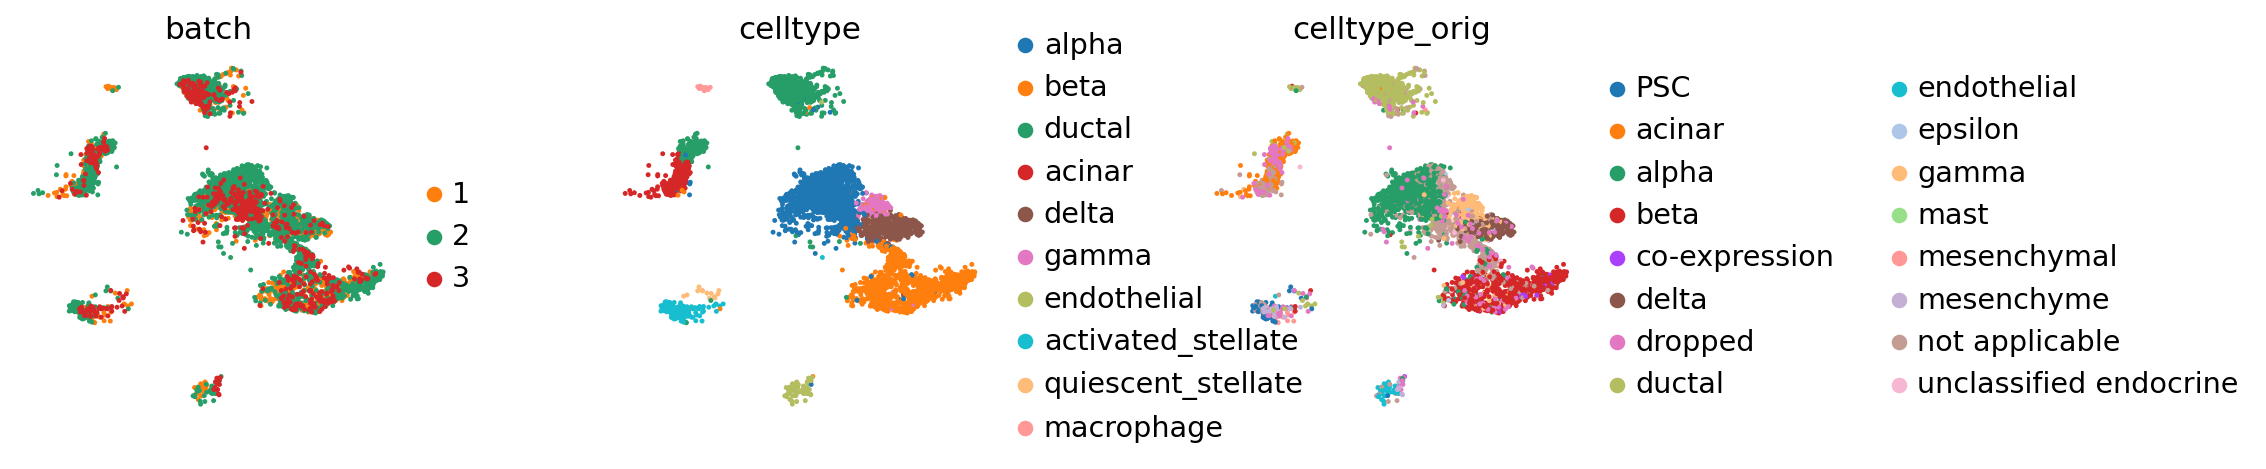

In [ ]:
sc.pl.umap(adata_query, color=["batch", "celltype", "celltype_orig"], wspace=0.4)

#### Cell types conserved across batches

Let us first focus on cell types that are conserved with the reference, to simplify reading of the confusion matrix.

In [ ]:
# intersected categories
conserved_categories = adata_query.obs["celltype"].cat.categories.intersection(
    adata_query.obs["celltype_orig"].cat.categories
)
# intersect categories
obs_query_conserved = adata_query.obs.loc[
    adata_query.obs["celltype"].isin(conserved_categories) & adata_query.obs["celltype_orig"].isin(conserved_categories)
].copy()
# remove unused categories
obs_query_conserved["celltype"] = obs_query_conserved["celltype"].cat.remove_unused_categories()
# remove unused categories and fix category ordering
obs_query_conserved["celltype_orig"] = (
    obs_query_conserved["celltype_orig"]
    .cat.remove_unused_categories()
    .cat.reorder_categories(obs_query_conserved["celltype"].cat.categories)
)

In [ ]:
pd.crosstab(obs_query_conserved["celltype"], obs_query_conserved["celltype_orig"])

celltype_orig,alpha,beta,ductal,acinar,delta,gamma,endothelial
celltype,,,,,,,
alpha,1815,3,13,0,1,20,0
beta,52,805,6,1,11,39,0
ductal,7,6,685,241,0,0,0
acinar,2,3,3,166,0,3,0
delta,6,3,0,0,304,72,0
gamma,1,5,0,1,0,182,0
endothelial,2,0,0,0,0,0,36


Overall, the conserved cell types are also mapped as expected. The main exception are some acinar cells in the original annotation that appear as acinar cells. However, already the reference data is observed to feature a cluster of both acinar and ductal cells, which explains the discrepancy, and indicates a potential inconsistency in the initial annotation.

#### All cell types

Let us now move on to look at all cell types.

In [ ]:
pd.crosstab(adata_query.obs["celltype"], adata_query.obs["celltype_orig"])

celltype_orig,PSC,acinar,alpha,beta,co-expression,delta,dropped,ductal,endothelial,epsilon,gamma,mast,mesenchymal,mesenchyme,not applicable,unclassified endocrine
celltype,,,,,,,,,,,,,,,,
alpha,0,0,1815,3,3,1,35,13,0,4,20,7,0,0,305,8
beta,1,1,52,805,36,11,40,6,0,0,39,0,0,1,521,25
ductal,0,241,7,6,0,0,41,685,0,0,0,0,2,0,99,1
acinar,0,166,2,3,0,0,24,3,0,0,3,0,0,0,90,0
delta,0,0,6,3,0,304,13,0,0,5,72,0,0,0,98,7
gamma,0,1,1,5,0,0,2,0,0,1,182,0,0,0,15,0
endothelial,1,0,2,0,0,0,7,0,36,0,0,0,0,6,7,0
activated_stellate,48,1,1,2,0,0,11,7,0,0,0,0,78,20,17,0
quiescent_stellate,4,0,1,1,0,0,5,1,1,0,0,0,0,0,1,0


We observe that PSC ([pancreatic stellate cells](https://en.wikipedia.org/wiki/Pancreatic_stellate_cell)) cells are in fact just inconsistently annotated and correctly mapped on 'activated_stellate' cells.

Also, it's nice to see that 'mesenchyme' and 'mesenchymal' cells both map onto the same category. However, that category is again 'activated_stellate' and likely incorrect.

### Visualizing distributions across batches

Often, batches correspond to experiments that one wants to compare. Scanpy offers to convenient visualization possibilities for this.

1. a density plot
2. a partial visualization of a subset of categories/groups in an emnbedding

#### Density plot

In [ ]:
sc.tl.embedding_density(adata_concat, groupby="batch")

computing density on 'umap'


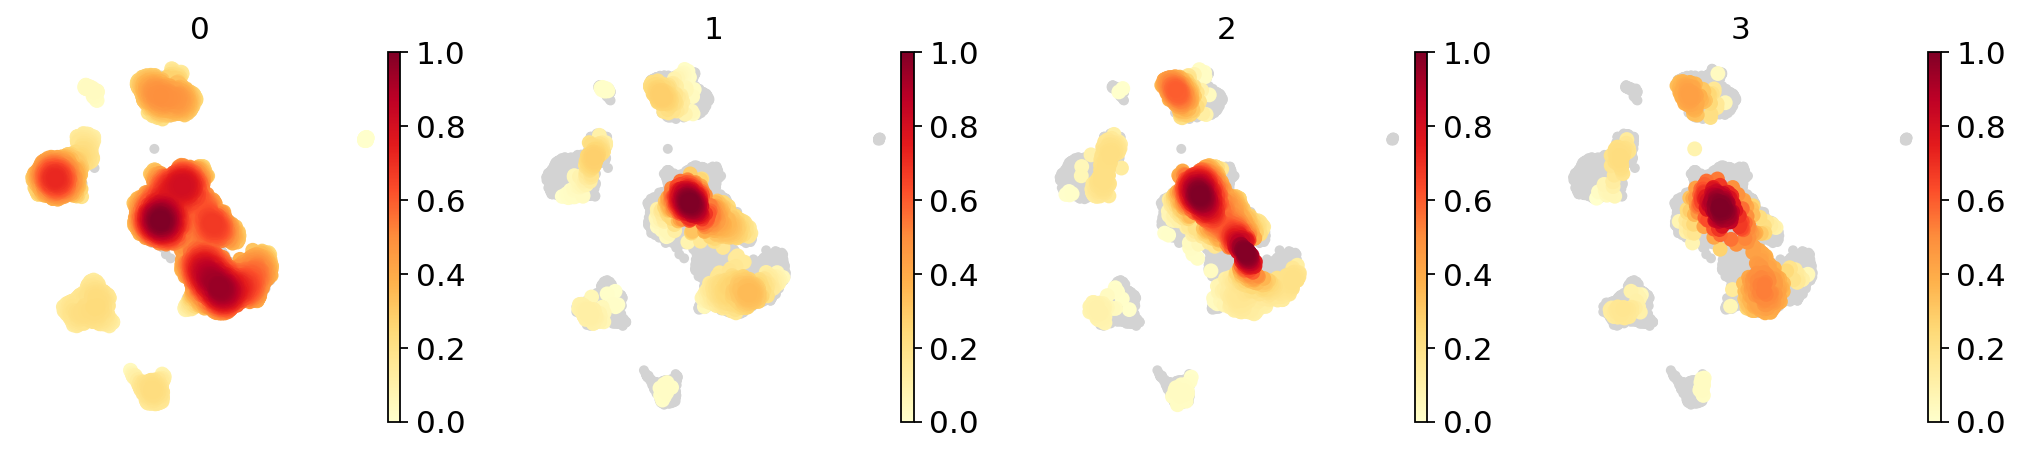

In [ ]:
sc.pl.embedding_density(adata_concat, groupby="batch")

#### Partial visualizaton of a subset of groups in embedding

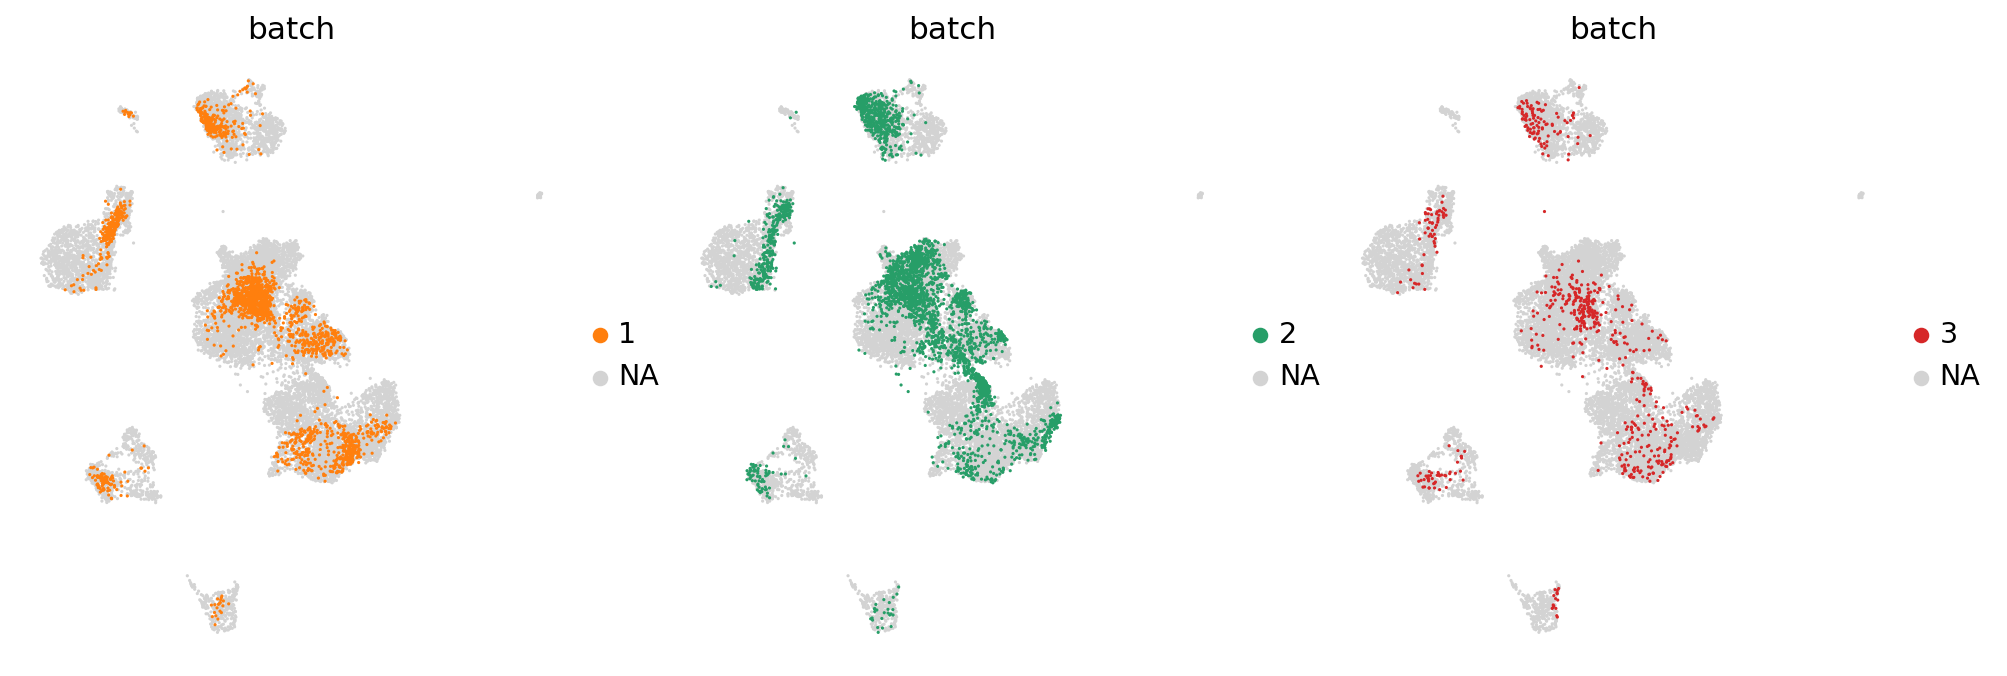

In [ ]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for batch, ax in zip(["1", "2", "3"], axes, strict=True):
    sc.pl.umap(adata_concat, color="batch", groups=[batch], ax=ax, show=False)